# **Running Aurora with GEFS-Control and GEFS-Aerosols Initial Conditions**

**[Microsoft Aurora](https://github.com/microsoft/aurora)** is a machine learning, foundational, model of the Earth system that has been pre-trained on various reanalysis and analysis datasets (i.e., ERA5, GFS, GEFS). To allow for *air pollution* forecasting, Aurora was fine-tuned on [CAMS](https://atmosphere.copernicus.eu/) Analysis and Reanalysis data spanning 2003 to 2022.

Despite being fine-tuned and intended for use with CAMS, we can replace some initial condition data from CAMS with corresponding data from [GEFS-Aerosols](https://www.arl.noaa.gov/research/surface-atmosphere-exchange-home/tools-and-products/gefs-aerosols/) and GEFS-Control meteorology and ozone. This allows us to explore Aurora's sensitivity to initial condition data and it's overall robustness at capturing air pollution episodes. The workflow for this code is visualized below...

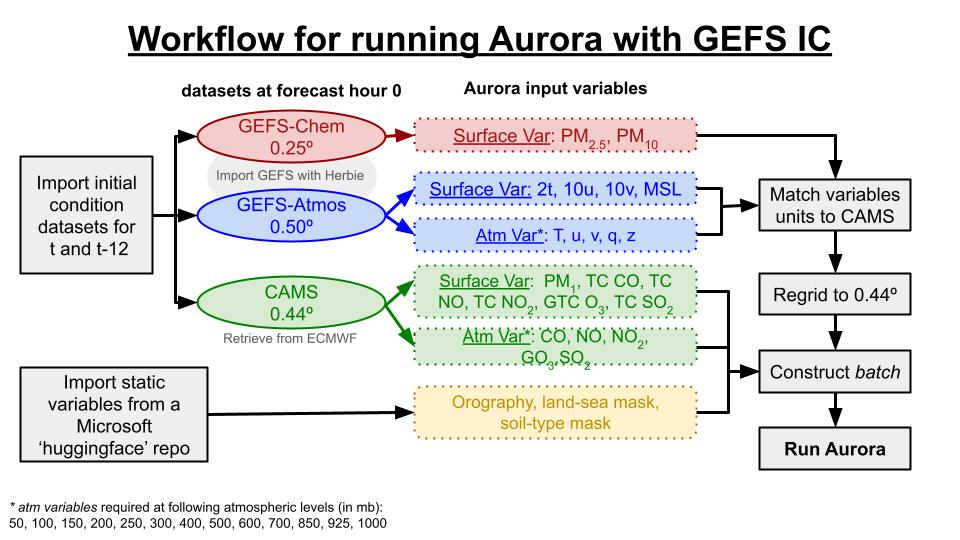

Regardless of data source, three datasets are needed as initial conditions for Aurora for batch creation.

*   **SURFACE** = meteorological variables at the surface
*   **ATMOSPHERE** = meteorological variables at various pressure levels
*   **STATIC** = variables that are dynamically fixed, in Air Pollution mode, this includes anthropogenic emissions and temporal predictors (i.e, DOY)

More information about batches can be found in [here](https://microsoft.github.io/aurora/batch.html)

In this notebook, we are targeting **surface PM2.5**  

**🚩 IMPORTANT!! 🚩** In order to run Aurora, it is *highly* recommended that you connect to an A100 GPU or T4 otherwise Aurora may run out of RAM and crash. The high ram A100 GPU is not required, but can speed up run time if running forecasts over multiple days.

# Prepare Python environment


Since Google Colab does n#ot natively support Conda, we need to pip install a few required packages. This will take 1-3 minutes

In [1]:
# install Aurora
!pip install microsoft-aurora

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.7/215.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.3 MB/s eta 0:00:00


In [2]:
# install Herbie; we will use this to retrieve GEFS data
!pip install 'herbie-data[extras]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 126.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.5/91.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.2/118.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 29.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found exi

In [3]:
# import remaining libraries
import zipfile
from pathlib import Path
import pickle
import torch
import xarray as xr
import pandas as pd
from aurora import Batch, Metadata
from aurora import AuroraAirPollution, rollout
import xarray as xr
from herbie import Herbie
import numpy as np
import shutil
import yaml
import os

 ╭─▌▌Herbie─────────────────────────────────────────────╮
 │ INFO: Created a default config file.                 │
 │ You may view/edit Herbie's configuration here:       │
 │          /root/.config/herbie/config.toml            │
 ╰──────────────────────────────────────────────────────╯



### create a custom function to export Aurora files to external directory

In [4]:
def export_aurora(nc_filepath_list, temp_dir_fp, output_dir_fp, zipped_filename, ):
  # for each forecast initialization, this function compresses all forecasts into a single zipped file for analysis
  #== input parameters ==
  # nc_filepath_list = list of netcdf files we will be compressing; each file will represent an individual forecast
  # temp_dir_fp = directory where netcdf files from Aurora are temporarily stored (really only relevant for Colab)
  # output_dir_fp = directory where we want to migrate our Aurora files to
  # zipped_filename = name of zipped file we will create


  # now, export each forecast initialization time to a zipped file
  directory_to_zip = Path(temp_dir_fp)

  # the base name for the zip file (path + filename without .zip extension), we will place the zip file one level up from the aurora_output_path
  zip_base_name = directory_to_zip.parent / zipped_filename

  # create zip file locally
  print(f"Compressing {directory_to_zip} to {zip_base_name}.zip")
  shutil.make_archive(zip_base_name, 'zip', directory_to_zip)
  print("Compression complete.")

  print('Purging netcdf files...')
  # now, purge directory of files locally, do this to save space and prevent the compressed zip files from growing infintely larger (could alter this to filter for subset of strings)
  substring = "target_string"
  for file_path in directory_to_zip.iterdir():
      if file_path.is_file() and file_path.name in nc_filepath_list:
          file_path.unlink()
          print(f"Deleted: {file_path}")

  print('Files purged.')
  # define the destination path in outfir directory
  # create a subdirectory named after exp_name within gdrive_data_path
  # ensure the destination directory exists; if not make it
  output_dir_fp.mkdir(parents=True, exist_ok=True)
  # construct the full path to the source zip file
  source_zip_file_path = Path(str(zip_base_name) + '.zip')
  # construct the destination file path on Google Drive
  destination_file_path = output_dir_fp / source_zip_file_path.name
  # copy the zip file to Google Drive
  shutil.copy(source_zip_file_path, destination_file_path)
  print("Zip file successfully copied from ", source_zip_file_path, " to ", destination_file_path)
  print('-------------------------')
  print('\n')

## create folders and import CAMS data

In [5]:
from pathlib import Path

# create a folder to store Aurora output
download_path = Path("Aurora_forecasts") # edit this path if you'd like
download_path.mkdir(parents=True, exist_ok=True)

In [7]:
# mount to Google Drive to pull zipped CAMS Forecast data

# if running Aurora on small datasets (<3 days of IC), retrieve locally from ECWMF
# since computing resources on Google Colab are time-limited, it's quicker to retrieve
#   data from ECWMF ahead of time and import when running Aurora

from google.colab import drive
drive.mount('/content/gdrive')
gdrive_data_path = '/content/gdrive/My Drive/Ellie Hojeily NERTO-NOAA EMC 2026/data/' # again, modify this path/cell block accordingly
cams_fcst_zip = 'summer-case-cams-forecast.nc.zip'

# this will create a folder in 'Files' called 'gdrive' which has a copy of your Google Drive

# move CAMS data from gdrive to local directory
cams_download_path = Path("cams") # local path for CAMS data
cams_download_path = cams_download_path.expanduser()
cams_download_path.mkdir(parents=True, exist_ok=True)

if not (cams_download_path / cams_fcst_zip).exists():
  # move CAMS data from GoogleDrive to local directory if not already imported...
  shutil.copy(gdrive_data_path+cams_fcst_zip, cams_download_path)
  print(cams_fcst_zip,' moved from ', gdrive_data_path, ' to ', cams_download_path)
else:
  print(cams_fcst_zip, ' already imported.')

Mounted at /content/gdrive
summer-case-cams-forecast.nc.zip  moved from  /content/gdrive/My Drive/Ellie Hojeily NERTO-NOAA EMC 2026/data/  to  cams


In [8]:
# now, unpack the locally stored CAMS data
surface_level_filename = "summer-case-CAMS-fcst-surface-level.nc" # surface variables
atmospheric_filename = "summer-case-CAMS-fcst-atmospheric.nc" # atmosphere variables
# unpack the ZIP. It should contain the surface-level and atmospheric data in separate files
# updated paths to use variables and f-strings for consistency.
if not (cams_download_path / surface_level_filename).exists():
    with zipfile.ZipFile(cams_download_path / cams_fcst_zip, "r") as zf, open(
        cams_download_path / surface_level_filename, "wb"
    ) as f:
        f.write(zf.read("data_sfc.nc"))
if not (cams_download_path / atmospheric_filename).exists():
    with zipfile.ZipFile(cams_download_path / cams_fcst_zip, "r") as zf, open(
        cams_download_path / atmospheric_filename, "wb"
    ) as f:
        f.write(zf.read("data_plev.nc"))
print("Surface-level and atmospheric variables downloaded!")

Surface-level and atmospheric variables downloaded!


In [9]:
# and create xarray datasets for our CAMS datasets

# xarray for our atmospheric variables from CAMS
atmos_vars_ds = xr.open_dataset(
    cams_download_path / atmospheric_filename,
    engine="netcdf4", decode_timedelta=True)
# xarray for our surface level variables from CAMS
surf_vars_ds = xr.open_dataset(
    cams_download_path / surface_level_filename,
    engine="netcdf4", decode_timedelta=True)

## import static variables from Microsoft

Aurora Air Pollution requires static variables that must be retrieved from Microsoft. In the future, NOAA should probably investigate modifying/adding to these

In [10]:
# download the static variables from HuggingFace; you will need to get an API
#   a secret token can be made for this on Google Colab (highly recommend!)
from huggingface_hub import hf_hub_download
static_path = hf_hub_download(
    repo_id="microsoft/aurora",
    filename="aurora-0.4-air-pollution-static.pickle",
)
print("Static variables downloaded!")

aurora-0.4-air-pollution-static.pickle:   0%|          | 0.00/17.9M [00:00<?, ?B/s]

Static variables downloaded!


In [11]:
# ... and load static variables
with open(static_path, "rb") as f:
    static_vars = pickle.load(f)

/tmp/ipykernel_452/1413347137.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  static_vars = pickle.load(f)


# Compare CAMS to GEFS variables

Since Aurora was fine-tuned on CAMS data, we want to make sure variables exactly match in units, otherwise Aurora will hallucinate. Below are tables comparing the required variables; yellow indicates variables that will need to be converted from GEFS and red indicates variables missing from GEFS.



 🚩**IMPORTANT!!** 🚩 When we run Aurora with only GEFS-Aerosol initial conditions, *only PM2.5 and PM10* are input from GEFS.

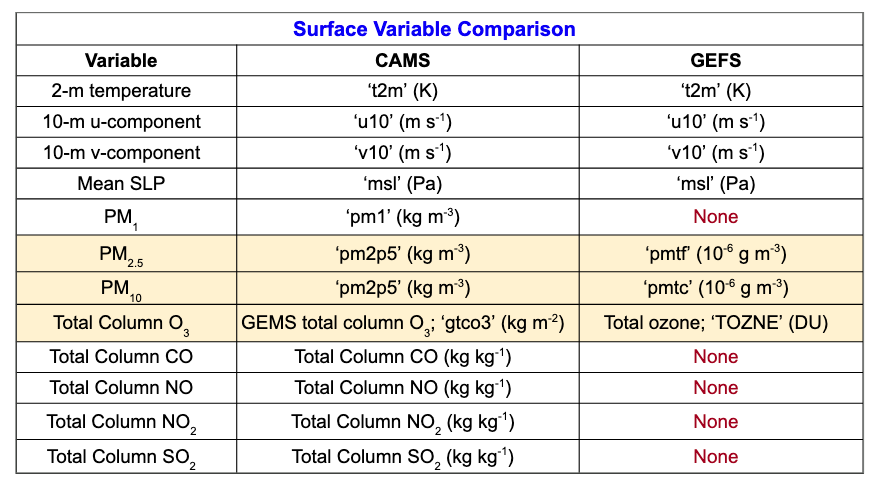

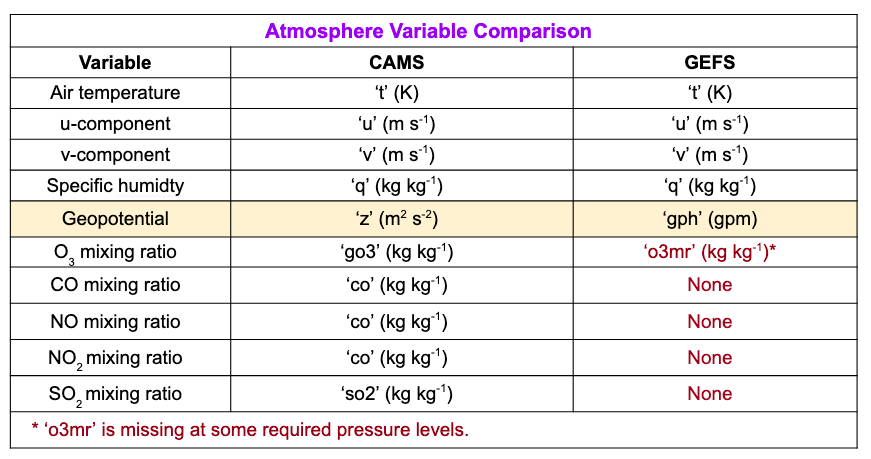

**any missing variable from GEFS is replaced with the corresponding variable from CAMS**

# Retrieving GEFS data using Herbie

GEFS variables are aggregated into files based on if the parameters are commonly used or not. We will need to read in both of the files for GEFS-Atmos for our control run meteorology and ozone data

We create a function called ```retrieve_gefs_atmos``` and use [Herbie](https://herbie.readthedocs.io/en/latest/gallery/noaa_models/gefs.html) to retrieve GEFS-Control GRIB files from AWS

In [12]:
def retrieve_gefs_atmos(t,variables,verbose=False):
  # for a specific time 't', this function returns GEFS-Atmos data at forecast hour 0 (analysis product)
  # == INPUTS ==
  # t = forecast hour we are interested in
  # variables = list of variables we want to retrieve from GEFS-Atmos
  # verbose = indicate if you want to be notified of what variables are retrieved and other useful print statements, good for debugging

  H_t0b = Herbie(
      pd.to_datetime(t[0]).strftime('%Y-%m-%d %H'),
      model="gefs",
      product="atmos.5b",
      member="c00",
      fxx=00 # forecast hour
  )

  H_t0 = Herbie(
      pd.to_datetime(t[0]).strftime('%Y-%m-%d %H'),
      model="gefs",
      product="atmos.5",
      member="c00",
      fxx=00 # forecast hour
  )


  H_t0.PRODUCTS
  # retrieve atm variables at required pressure levels from .b file

  pressure_levels = ['2 m above ground','10 m above ground',50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
  ds_list  = []
  da_list = []

  for variable in variables:
    if variable == 'PRMSL' or variable == 'TOZNE':
      continue # these are added at the end
    for pressure_level in pressure_levels:
      if variable == 'TMP' and pressure_level == '2 m above ground': # retrieve 2-t
        search_str = ":"+variable+":"+str(pressure_level)+":anl:ENS=low-res ctl:"
        str_array = H_t0.xarray(search_str)
        ds_list.append(str_array)
        if verbose == True:
          print('Successfully retrieved = ', search_str, ' from atmos.5 file')
        continue
      if variable != 'TMP' and pressure_level == '2 m above ground': # skip 2-m AGL for non temp terms
        continue

      if pressure_level == '10 m above ground':
        if variable == 'UGRD' or variable == 'VGRD':
          search_str = ":"+variable+":"+str(pressure_level)+":anl:ENS=low-res ctl:"
          str_array = H_t0.xarray(search_str)
          ds_list.append(str_array)
          if verbose == True:
            print('Successfully retrieved = ', search_str, ' from atmos.5 file')

        if variable not in ['UGRD', 'VGRD']:
            continue

      try:
        search_str = ":"+variable+":"+str(pressure_level)+" mb:anl:ENS=low-res ctl:"
        str_array = H_t0b.xarray(search_str).expand_dims({"isobaricInhPa": [pressure_level]})
        da_list.append(str_array)
        if verbose == True:
          print('Successfully retrieved = ', search_str, ' from atmos.5b file')

      except:
        try:
          search_str = ":"+variable+":"+str(pressure_level)+" mb:anl:ENS=low-res ctl:"
          str_array = H_t0.xarray(search_str).expand_dims({"isobaricInhPa": [pressure_level]})
          da_list.append(str_array)
          if verbose == True:
            print('Successfully retrieved = ', search_str, ' from atmos.5 file')

        except:
          if verbose == True:
            print('File not found = ', search_str)
          continue

  # add MSL to surface variables
  if 'PRMSL' in variables:
    search_str = ":PRMSL:mean sea level:anl:ENS=low-res ctl:"
    str_array = H_t0.xarray(search_str)
    ds_list.append(str_array)
    if verbose == True:
      print('Successfully retrieved = ', search_str, ' from atmos.5 file')

  # add total column O3 to surface variables
  if 'TOZNE' in variables:
    search_str = 'TOZNE'
    str_array = H_t0b.xarray(search_str)
    ds_list.append(str_array)
    if verbose == True:
      print('Successfully retrieved = ', search_str, ' from atmos.5b file')

    # concat to datasets
    print('Concating...')
  ds_gefs_met = xr.merge(ds_list,compat='override', join='outer')
  da_gefs_met = xr.merge(da_list,compat='no_conflicts', join='outer')

  da_gefs_met = da_gefs_met.rename({'isobaricInhPa':'pressure_level'})
  da_gefs_met=da_gefs_met.sortby('pressure_level', ascending=False)


  output_dict = {'ds_gefs_surf':ds_gefs_met, 'da_gefs_atmos':da_gefs_met}
  return output_dict

# **Running Aurora**

**LOAD AURORA CHECKPOINT**

In [13]:
from aurora import AuroraAirPollution, rollout, Batch

model = AuroraAirPollution()

print('Loading Aurora checkpoint... ')
model.load_checkpoint("microsoft/aurora", "aurora-0.4-air-pollution.ckpt")
model = model.to("cuda")
print('Aurora checkpoint loaded.')


Loading Aurora checkpoint... 


aurora-0.4-air-pollution.ckpt:   0%|          | 0.00/5.10G [00:00<?, ?B/s]

Aurora checkpoint loaded.


**CONFIGURING AURORA**

In [14]:
# get current time as we want to track when Aurora was run.
from datetime import datetime, timezone
current_time_utc = datetime.now().strftime("%Y-%m-%d %H:%M:%S")


In [15]:
# configure Aurora here! [can convert to yaml file later]
#     multiple Aurora configurations can created here; each saved as a dictionary embedded into the aurora_configurations dictionary

aurora_configurations = {
        'june-2023-cams-rem-go3-nox':{
              # give our experiment a name; later if we save the output, the nc files will use this string to ID them (required)
          'lead_time_days':5, # specify the number of days we want to forecast out for. (DEFAULT: 5-days to match GEFS-Aerosols)
          'remove_atmos_variables':['go3','no','no2'], # atmosphere variables we will remove (*optional*) (DEFAULT: no variables removed! [])
          'remove_surf_variables':['gtco3','tc_no','tcno2'], # surface variables we will remove (*optional*) (DEFAULT: no variables removed! [])
          'use_gefs_ozone': False, # if True, use O3 data from GEFS-Control (DEFAULT: False)
          'use_gefs_aero': False, # if True, use PM2.5 and PM10 from GEFS-Aerosols (DEFAULT: False)
          'use_gefs_met': False, # if True, use meteorology from GEFS-Control (DEFAULT: False)
          'regrid_method': 'nearest', # for regridding GEFS (rec 'nearest' or 'linear'), specify method (ref: https://xarray-regrid.readthedocs.io/en/latest/autoapi/xarray_regrid/index.html)
          'specify_forecast_range': True, # if True, use user specified forecast start and end; if False, the full available data from CAMS will be assumed to be the range (DEFAULT: False)
          'forecast_start': '2023-06-01 12', # first day of forecast initialization (DEFAULT: empty string '')
          'forecast_end': '2023-06-10 12', # last day of forecast initialization (DEFAULT: empty string '')
          'restrict_NA_onsave':True, # if True, restrict saved Aurora files to only North America; if False, global data are saved  (DEFAULT: True)
          'save_aurora_output':True, # if True, Aurora output (DEFAULT: False)
          'save_aurora_output_dir':'', # filepath where Aurora files will be zipped and compressed to (DEFAULT: '')
          'date_experiment_ran':current_time_utc # timestamp script is being run
        }
        }


In [16]:
print('Number of Aurora configurations we are running = ', len(aurora_configurations.keys()))

Number of Aurora configurations we are running =  1


### Now, create batches and input into Aurora

In [17]:
 for aurora_configuration in aurora_configurations.keys():

  # create variable for our configration parameters
  configure_params = aurora_configurations[aurora_configuration]


  print('Running Aurora for Experiment: '+aurora_configuration)
  print('\n')

  # check that we have sufficient data from CAMS
  # construct an array of valid forecast initialization times based on the available data from CAMS
  valid_cams_times_array = surf_vars_ds.valid_time.values

  # if a forecast date range is specified, check that we have the necessary CAMS data
  if configure_params['specify_forecast_range'] == True:
    forecast_array = pd.date_range(start=configure_params['forecast_start'], end=configure_params['forecast_end'], freq='12h')
    forecast_array = forecast_array.to_numpy().astype('datetime64[ns]') # freq of 12 hours to match Aurora resolution
    if forecast_array in valid_cams_times_array:
      mask = np.isin(forecast_array, valid_cams_times_array)
      if len(mask[mask == True]) != len(forecast_array): # checks that we have sufficient CAMS data in our requested date range
        print(*'Missing CAMS data for requested date range. Adjust forecast start/end OR retrieve more CAMS data!*')
        print('\n')
      if len(mask[mask == True]) == len(forecast_array): # checks that we have sufficient CAMS data in our requested date range
        print('*All CAMS data imported for requested date range.*')
        print('\n')
    forecast_array=forecast_array.reshape(-1, 1) # reshape to match valid_times; ensure Aurora loops through both the same

  # if a forecast date range is not specified, use all available cams data
  if configure_params['specify_forecast_range'] == False:
    forecast_array = valid_cams_times_array.copy()


  print('== Model Configuration == ')
  print('Forecast lead time  = ', str(configure_params['lead_time_days']),' days')
  print('First forecast init = ', pd.to_datetime(forecast_array[0]).strftime('%Y-%m-%d %H UTC')[0])
  print('Last forecast init  = ', pd.to_datetime(forecast_array[-1]).strftime('%Y-%m-%d %H UTC')[0])
  print('Regridding GEFS method = ', configure_params['regrid_method'] )
  print('\n')
  print('== Chemistry and Meteorology ==')
  if configure_params['use_gefs_ozone'] == True:
    print('Ozone               =  GEFS-Control 0.5 deg')
  if configure_params['use_gefs_ozone'] == False:
    print('Ozone               =  CAMS')

  if configure_params['use_gefs_aero'] == True:
    print('Aerosol (PM2.5,10)  =  GEFS-Chem 0.25 deg')
  if configure_params['use_gefs_aero'] == False:
    print('Aerosol (PM2.5,10)  =  CAMS')

  if configure_params['use_gefs_met'] == True:
    print('Meteorology         =  GEFS-Control 0.5 deg')
  if configure_params['use_gefs_met'] == False:
    print('Meteorology         =  CAMS')


  for t0 in forecast_array:
    t12 =  (pd.to_datetime(pd.to_datetime(t0).strftime('%Y-%m-%d %H UTC')) - pd.Timedelta(hours=12))

    # check that the previous 12 hour forecast is present in our CAMS data; if not continue
    if t12[0].to_numpy() not in valid_cams_times_array:
        print('Cannot initialize forercast for '+pd.to_datetime(t0[0]).strftime('%Y-%m-%d %H UTC'))
        print('Missing previous 12-hour forecast!')
        print('Continuing to next hour... ')
        continue

    print('\n')
    print('== Preparing NetCDF Files ==')

    print('Initializing forecast '+pd.to_datetime(t0[0]).strftime('%Y-%m-%d %H UTC'))
    print('Previous 12-Hour forecast = '+pd.to_datetime(t12[0]).strftime('%Y-%m-%d %H UTC'))
    print('\n')


    surf_vars_dict = {} # append our surface variables here
    atmos_vars_dict = {} # append our atmosphere variables here

    # start by preparing our CAMS IC

    # generate data arrays with required t and t12 data []
    # get index in CAMS data corresponding to our necessary forecast initialization (t0) and previous 12-hours (t12)
    idx_t0 = np.where(valid_cams_times_array == t0)[0].item()
    idx_tprev = np.where(valid_cams_times_array == t12[0].to_numpy())[0].item()

    # subset CAMS data to t0 and t12
    ds = surf_vars_ds.isel(forecast_reference_time=[idx_tprev,idx_t0])
    da = atmos_vars_ds.isel(forecast_reference_time=[idx_tprev,idx_t0])

    # redudant; but ensure we only get forecast hour 0 (aka analysis product)
    ds = ds.isel(forecast_period=0)
    da = da.isel(forecast_period=0)

    da = da.copy()
    ds = ds.copy()
    # assume we want all variables from CAMS initially, we were overrwrite with user defined configurations later

    # SURFACE VARIABELES
    surf_vars_dict['2t'] = ds['t2m'].copy()
    surf_vars_dict['10u'] = ds['u10'].copy()
    surf_vars_dict['10v'] = ds['v10'].copy()
    surf_vars_dict['msl'] = ds['msl'].copy()
    surf_vars_dict['pm1'] = ds['pm1'].copy()
    surf_vars_dict['pm2p5'] = ds['pm2p5'].copy()
    surf_vars_dict['pm10'] = ds['pm10'].copy()
    surf_vars_dict['tcco'] = ds['tcco'].copy()
    surf_vars_dict['tc_no'] = ds['tc_no'].copy()
    surf_vars_dict['tcno2'] = ds['tcno2'].copy()
    surf_vars_dict['gtco3'] = ds['gtco3'].copy()
    surf_vars_dict['tcso2'] = ds['tcso2'].copy()

    # ATMOSPHERE VARIABLES
    atmos_vars_dict['t'] = da['t'].copy()
    atmos_vars_dict['u'] = da['u'].copy()
    atmos_vars_dict['v'] = da['v'].copy()
    atmos_vars_dict['q'] = da['q'].copy()
    atmos_vars_dict['z'] = da['z'].copy()
    atmos_vars_dict['co'] = da['co'].copy()
    atmos_vars_dict['no'] = da['no'].copy()
    atmos_vars_dict['no2'] = da['no2'].copy()
    atmos_vars_dict['go3'] = da['go3'].copy()
    atmos_vars_dict['so2'] = da['so2'].copy()


    ## adding GEFS IC where necessary
    if configure_params['use_gefs_aero'] == True:
      # retrieve GEFS-Chem Analysis from Herbie

      # forecast initialization (t0)
      H_t0 = Herbie(
          pd.to_datetime(t0[0]).strftime('%Y-%m-%d %H'),
          model="gefs",
          product="chem.5",
          member="c00",
          fxx=00 # forecast hour
      )

      d_gefs_aero_t0 = H_t0.xarray('PMTF.*aerosol=Total Aerosol|PMTC.*aerosol=Total Aerosol')

      # forecast initialization (t12)
      H_t12 = Herbie(
          pd.to_datetime(t12[0]).strftime('%Y-%m-%d %H') ,
          model="gefs",
          product="chem.5",
          member="c00",
          fxx=00 # forecast hour
      )

      d_gefs_aero_t12 = H_t12.xarray('PMTF.*aerosol=Total Aerosol|PMTC.*aerosol=Total Aerosol')

      # combine GEFS datasets
      ds_gefs_aero = xr.concat([d_gefs_aero_t12, d_gefs_aero_t0], dim="time", coords='different', compat='equals')
      ds_gefs_aero = ds_gefs_aero.rename({'time':'forecast_reference_time'})
      ds_gefs_aero = ds_gefs_aero.rename({"pmtf": "pm2p5"})
      ds_gefs_aero = ds_gefs_aero.rename({"pmtc": "pm10"})

      # order forecasts like CAM (IMPORTANT as Aurora uses this difference, without this the sign of the difference may be wrong)
      ds_gefs_aero = ds_gefs_aero.sortby('forecast_reference_time', ascending=True)

      # regrid GEFS to CAMS
      ds_gefs_aero = ds_gefs_aero.interp(longitude=ds.longitude, latitude=ds.latitude,
                                         method=configure_params['regrid_method'])

      # PM unit conversion
      ds_gefs_aero['pm2p5'] = ds_gefs_aero['pm2p5']/1e9
      ds_gefs_aero['pm10'] = ds_gefs_aero['pm10']/1e9

      # now, append to surf_vars_dict to override CAMS
      surf_vars_dict['pm2p5'] = ds_gefs_aero['pm2p5'].copy()
      surf_vars_dict['pm10'] = ds_gefs_aero['pm10'].copy()

    # build list of gefs atmos variables we need to retrieve
    if configure_params['use_gefs_met'] == True or configure_params['use_gefs_ozone'] == True:
      gefs_atmos_variables = []
      if configure_params['use_gefs_met'] == True:
        gefs_atmos_variables = gefs_atmos_variables+['TMP','UGRD','VGRD','SPFH','HGT','PRMSL']
      if configure_params['use_gefs_ozone'] == True:
          gefs_atmos_variables = gefs_atmos_variables+['TOZNE','O3MR']

      # get GEFS-Control atmosphereic data
      #   recommend verbose set to False when retrieving files in bulk
      dict_gefs_atmos_t0 = retrieve_gefs_atmos(t=t0, variables=gefs_atmos_variables, verbose=False)
      dict_gefs_atmos_t12 = retrieve_gefs_atmos(t=t12, variables=gefs_atmos_variables, verbose=False)

      # create surface (ds) and atmosphere (da) datasets
      ds_gefs_atmos = xr.concat([dict_gefs_atmos_t12['ds_gefs_surf'],
                              dict_gefs_atmos_t0['ds_gefs_surf']]
                              , dim="time",coords='different',compat='equals')
      da_gefs_atmos = xr.concat([dict_gefs_atmos_t12['da_gefs_atmos'],
                              dict_gefs_atmos_t0['da_gefs_atmos']]
                              , dim="time",coords='different',compat='equals')

      # match time dimension name to CAMS
      da_gefs_atmos = da_gefs_atmos.rename({'time':'forecast_reference_time'})
      ds_gefs_atmos = ds_gefs_atmos.rename({'time':'forecast_reference_time'})

      # sort time dimension to ascending
      da_gefs_atmos = da_gefs_atmos.sortby('forecast_reference_time', ascending=True)
      ds_gefs_atmos = ds_gefs_atmos.sortby('forecast_reference_time', ascending=True)


      # regrid GEFS-Control to CAMS (0.5 to 0.44)
      ds_gefs_atmos = ds_gefs_atmos.interp(longitude=ds.longitude, latitude=ds.latitude,
                                           method=configure_params['regrid_method'],kwargs={"fill_value": "extrapolate"})
      da_gefs_atmos = da_gefs_atmos.interp(longitude=da.longitude, latitude=da.latitude, pressure_level=da.pressure_level,
                                           method=configure_params['regrid_method'],kwargs={"fill_value": "extrapolate"})


      if configure_params['use_gefs_ozone'] == True:
        # convert total columns ozone from Dobson Units to kg/m^2
        # (ref; https://sacs.aeronomie.be/info/dobson.php)
        ds_gefs_atmos['tozne']=ds_gefs_atmos['tozne']*((2.1415)*(10**(-5)))

        # not all vertical levels of GEFS-Atmos has O3 data, in order for Aurora to run, we need to supplement with CAMS
        #     specifically we will use CAMS O3 from 1000 mb to 500 mb, then from 400 mb to 50 mb we will use GEFS
        cams_subset_go3_ge500mb = da['go3'].sel(pressure_level=da['go3'].pressure_level[da['go3'].pressure_level >= 500]) # select column O3 greater than 500 mb from CAMS
        gefs_subset_go3_l500mb = da_gefs_atmos['o3mr'].sel(pressure_level=da_gefs_atmos['o3mr'].pressure_level[da['go3'].pressure_level < 500]) # select column O3 less than 500 mb from GEFS
        gefs_subset_go3_l500mb=gefs_subset_go3_l500mb.rename('go3') # rename to match CAMS
        gefs_subset_go3_l500mb = gefs_subset_go3_l500mb.sortby('forecast_reference_time', ascending=True)
        merge_go3 = xr.merge([gefs_subset_go3_l500mb,cams_subset_go3_ge500mb], join='outer',compat='no_conflicts')
        merge_go3 = merge_go3.rename({'go3':'merged_cams_gefs_o3'})  # now regrid all data to match CAMS

        # append to surf_vars_dict to override CAMS
        surf_vars_dict['gtco3'] = ds_gefs_atmos['tozne'].copy()

        # append to atmos_vars_dict to override CAMS
        atmos_vars_dict['go3'] = merge_go3['merged_cams_gefs_o3'].copy()

      if configure_params['use_gefs_met']== True:
        # geopotential height to geopotential conversion
        da_gefs_atmos['z'] = da_gefs_atmos['gh']*9.80665

        # append to surf_vars_dict to override CAMS
        surf_vars_dict['2t'] = ds_gefs_atmos['t2m'].copy()
        surf_vars_dict['10u'] = ds_gefs_atmos['u10'].copy()
        surf_vars_dict['10v'] = ds_gefs_atmos['v10'].copy()
        surf_vars_dict['msl'] = ds_gefs_atmos['prmsl'].copy()

        # append to atmos_vars_dict to override CAMS
        atmos_vars_dict['t'] = da_gefs_atmos['t'].copy()
        atmos_vars_dict['u'] = da_gefs_atmos['u'].copy()
        atmos_vars_dict['v'] = da_gefs_atmos['v'].copy()
        atmos_vars_dict['q'] = da_gefs_atmos['q'].copy()
        atmos_vars_dict['z'] = da_gefs_atmos['z'].copy()

    # Apply Sensitivity Test Configurations
    # remove specified atmosphere vars
    for variable in configure_params['remove_atmos_variables']:
      del atmos_vars_dict[variable]

    # remove specified surface vars
    for variable in configure_params['remove_surf_variables']:
      del surf_vars_dict[variable]

    # construct torches
    # SURFACE
    surf_vars_torch = {}
    for surf_var in surf_vars_dict.keys():
      surf_vars_torch[surf_var] = torch.from_numpy(surf_vars_dict[surf_var].values[None])
    # ATMOSPHERE
    atmos_vars_torch = {}
    for atmos_var in atmos_vars_dict.keys():
      atmos_vars_torch[atmos_var] = torch.from_numpy(atmos_vars_dict[atmos_var].values[None])

    print('\n')
    print('Final atmospheric variables = ', list(surf_vars_torch.keys()))
    print('Final surface variables = ', list(atmos_vars_torch.keys()))
    print('\n')

    print('== Constructing Batches ==')
    # Now construct a batch!
    batch = Batch(
      surf_vars=surf_vars_torch,
      static_vars={k: torch.from_numpy(v) for k, v in static_vars.items()},
      atmos_vars=atmos_vars_torch,
      metadata=Metadata(
          lat=torch.from_numpy(da.latitude.values),
          lon=torch.from_numpy(da.longitude.values),
          # Converting to `datetime64[s]` ensures that the output of `tolist()` gives
          # `datetime.datetime`s.
          time=(da.valid_time.values.astype("datetime64[s]").tolist()[-1],),
          atmos_levels=tuple(int(level) for level in da.pressure_level.values),
      ),)



    print('Batch successfully created.')
    print('\n')
    print('== Running Aurora ==')

    # Now, run Aurora!
    model = model.to("cuda")
    with torch.inference_mode():
      print('Inference mode running.. ')
      predictions = [pred.to("cpu") for pred in rollout(model, batch, steps=(((configure_params['lead_time_days']+1)*2)))] # 2 forecats (0Z, 12Z) per day,

    model = model.to("cpu")
    print('Aurora forecast completed.')
    print('\n')

    # save experiment results locally at .nc files
    #iterate through each forecast hour generated; create a xarray dataset for each forecast hour and save output locally

    nc_filepath_list = [] # if exporting to google drive, this sorts files to zip
    for individual_forecast_hour in range(len(predictions)):
      aurora_forecast = predictions[individual_forecast_hour]
      aurora_lat = aurora_forecast.metadata.lat
      aurora_lon = aurora_forecast.metadata.lon

      aurora_valid = pd.to_datetime(aurora_forecast.metadata.time)

      # construct dataset with relevant fields; modify with whatever variables are needed for validation
      aurora_output_xr = xr.Dataset(
          {
          "u": (('atmos_levels','lat','lon'), aurora_forecast.atmos_vars["u"][0, 0].numpy()),
          "v": (('atmos_levels','lat','lon'), aurora_forecast.atmos_vars["v"][0, 0].numpy()),
          "z": (('atmos_levels','lat','lon'), aurora_forecast.atmos_vars["z"][0, 0].numpy()),
          "pm25": (('lat','lon'), aurora_forecast.surf_vars["pm2p5"][0, 0].numpy()*1e9), # convert to micrograms per meter cubed
          "t": (('lat','lon'), aurora_forecast.surf_vars["2t"][0, 0].numpy()),
          },

          coords={
              "lat": aurora_lat,
              "lon": aurora_lon,
              "atmos_levels": np.array(list(aurora_forecast.metadata.atmos_levels)),
              "step": aurora_forecast.metadata.rollout_step*12,
              "time": t0,
              "valid_time": aurora_valid.item(),
              "rollout": aurora_forecast.metadata.rollout_step
          },
      )

      print('== Preparing Aurora files for Export ==')
      if configure_params['save_aurora_output'] == True:
        # save only data over North America to save space
        if configure_params['restrict_NA_onsave'] == True:
            aurora_output_xr =  aurora_output_xr.sel(
                lat=slice(75, 0),
                lon=slice(220, 305)
            )

        # filename for the netcedf file
        file_name = aurora_configuration+'.'+pd.to_datetime(t0[0]).strftime('%Y%m%d')+'.t'+f'{pd.to_datetime(t0[0]).strftime('%H'):02}'+'z.f'+f'{aurora_forecast.metadata.rollout_step*12:03}'+'.nc'
        # save dataset as a netcdf
        aurora_output_xr.to_netcdf(download_path/file_name)
        nc_filepath_list.append(file_name)
        print('Saved Aurora output as ', file_name)


    zipped_filename = aurora_configuration+'.'+pd.to_datetime(t0[0]).strftime('%Y%m%d')+'.t'+f'{pd.to_datetime(t0[0]).strftime('%H'):02}'+'z'
    output_dir_fp = Path(gdrive_data_path) / 'aurora' / aurora_configuration
    export_aurora(nc_filepath_list, download_path, output_dir_fp, zipped_filename)

    print('\n')
    print('== Aurora forecast completed! ==')
    print('\n')


  # save a copy of our aurora configuration to a .yaml file
 with open(str(output_dir_fp)+'/aurora-config-runon-'+datetime.now().strftime("%Y%m%d%HZ")+'.yaml', 'w') as file:
    yaml.dump(aurora_configurations[aurora_configuration], file, default_flow_style=False, sort_keys=False)
    print('Exported .yaml file to ', str(output_dir_fp)+'/aurora-config-'+datetime.now().strftime("%Y%m%d%HZ")+'.yaml')

Running Aurora for Experiment: june-2023-cams-rem-go3-nox


*All CAMS data imported for requested date range.*


== Model Configuration == 
Forecast lead time  =  5  days
First forecast init =  2023-06-01 12 UTC
Last forecast init  =  2023-06-10 12 UTC
Regridding GEFS method =  nearest


== Chemistry and Meteorology ==
Ozone               =  CAMS
Aerosol (PM2.5,10)  =  CAMS
Meteorology         =  CAMS


== Preparing NetCDF Files ==
Initializing forecast 2023-06-01 12 UTC
Previous 12-Hour forecast = 2023-06-01 00 UTC




Final atmospheric variables =  ['2t', '10u', '10v', 'msl', 'pm1', 'pm2p5', 'pm10', 'tcco', 'tcso2']
Final surface variables =  ['t', 'u', 'v', 'q', 'z', 'co', 'so2']


== Constructing Batches ==
Batch successfully created.


== Running Aurora ==
Inference mode running.. 


/tmp/ipykernel_452/1411896251.py:275: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  lat=torch.from_numpy(da.latitude.values),


Aurora forecast completed.


== Preparing Aurora files for Export ==
Saved Aurora output as  june-2023-cams-rem-go3-nox.20230601.t12z.f012.nc
== Preparing Aurora files for Export ==
Saved Aurora output as  june-2023-cams-rem-go3-nox.20230601.t12z.f024.nc
== Preparing Aurora files for Export ==
Saved Aurora output as  june-2023-cams-rem-go3-nox.20230601.t12z.f036.nc
== Preparing Aurora files for Export ==
Saved Aurora output as  june-2023-cams-rem-go3-nox.20230601.t12z.f048.nc
== Preparing Aurora files for Export ==
Saved Aurora output as  june-2023-cams-rem-go3-nox.20230601.t12z.f060.nc
== Preparing Aurora files for Export ==
Saved Aurora output as  june-2023-cams-rem-go3-nox.20230601.t12z.f072.nc
== Preparing Aurora files for Export ==
Saved Aurora output as  june-2023-cams-rem-go3-nox.20230601.t12z.f084.nc
== Preparing Aurora files for Export ==
Saved Aurora output as  june-2023-cams-rem-go3-nox.20230601.t12z.f096.nc
== Preparing Aurora files for Export ==
Saved Aurora output as  jun